# Лабораторная 1 численные методы

Вариант 6

Найти корень нелинейного уравнения $$f(x)=\ln x+(x+1)^3=0$$ применяя следующие методы:

1. Метод простой итерации
2. Метод Ньютона
3. Метод хорд

Необходимо:
1. Отделить хотя бы один (если их несколько) корень уравнения графическим способом.
2. Выбрать начальное приближение $x^0$, исходя из выполнения условий теоремы о сходимости метода Ньютона.
3. Используя выбранное начальное приближение $x^0$, найти тремя вышеуказанными методами решение данного нелинейного уравнения с точностью $\varepsilon=10^{-7}$. Критерием останова итерационного процесса выбрать следующий: $|x^{k+1}-x^k| \le \varepsilon$
4. Сравнить методы по скорости сходимости (теоретически и практически) и точности (оценить величину невязки каждого метода).

### 1. Отделить хотя бы один корень уравнения графическим способом.
Зададим $f(x), f'(x), f''(x)$:
$$f'(x)=\frac{1}{x}+3(x+1)^2$$    $$f''(x)=-\frac{1}{x^2} +6(x+1)$$

In [ ]:
import math
def func_var_six(x: float)->float:
    return math.log(x) + (x+1)**3

def func_var_six_derivative(x: float)->float:
    return 1/x + 3*(x+1)**2

def func_var_six_second_derivative(x: float)->float:
    return -1/(x*x) + 6*(x+1)

FUNC = func_var_six
DERIV = func_var_six_derivative
S_DERIV = func_var_six_second_derivative

Построим график функции:

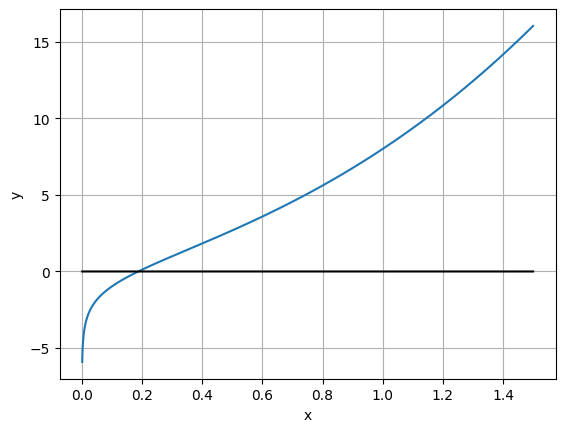

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.001, 1.5, 10000)
y = [FUNC(i) for i in x]

plt.plot(x, y)
plt.plot(x, np.zeros(len(x)), color="black")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

Как видно из графика, можно выделить отрезок $[0.1; 0.5]$, на котором корень будет единственным.

### 2. Выбрать начальное приближение $x^0$, исходя из выполнения условий теоремы о сходимости метода Ньютона.

##### Теорема:
Пусть:
1. $f(x)$ - определена и дважды дифференцируема на $S_0=[x^0;x^0+2h_0]$, $h_0=-\frac{f(x^0)}{f'(x^0)}$, при этом на концах $S_0$ $f'(x) \ne 0$.
2. Для начального приближения $x^0$ выполняется: $$2|h_0|M \le |f'(x^0)|, M=\max_{x \in S_0}|f''(x)|$$

Тогда:
1. Внутри отрезка $S_0$ уравнение $f(x)=0$ имеет корень $x^* \in S_0$ и при этом единственный.
2. Последовательное приближение $x^*,k=1,2,\dots$ может быть построено по формуле: $$x^{k+1}=x^k-\frac{f(x^k)}{f'(x^k)}$$
3. Последовательность $x^k$ сходится к корню $x^*$: $$\lim_{k \rightarrow \infty}x^k=x^*$$
4. Скорость сходимости характеризуется: $$|x^*-x^{k+1}| \le |x^{k+1}-x^k| \le \frac{M}{2|f'(x^k)|}|x^k-x^{k-1}|^2,\ k=1,2,\dots$$

#### Вычислим $h_0, M$

В качестве $x^0$ берём $0.5$. Вычислим $h_0$ и границы $S_0$. Построим график второй производной:

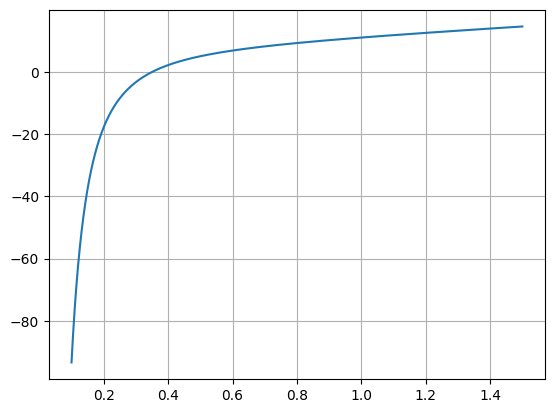

In [ ]:
x = np.linspace(0.1, 1.5, 10000)
y = [S_DERIV(i) for i in x]
plt.plot(x, y)
plt.grid()
plt.show()

Вторая производная - строго монотонно возрастающая функция, значит, в качестве $M$ берём верхнюю границу отрезка $S_0$.

In [ ]:
x_0 = 0.5
func_x_0 = FUNC(x_0)
deriv_x_0 = DERIV(x_0)
s_deriv_x_0 = S_DERIV(x_0)
h_0 = -func_x_0/deriv_x_0
M = math.fabs(s_deriv_x_0)
print(f"Function in x_0: {func_x_0:.4f}, derivative in x_0: {deriv_x_0}, second derivative in x_0: {s_deriv_x_0}")
print(f"h_0={h_0:.4f}, S_0=[{x_0 + 2*h_0:.4f}; {x_0}] M={M}")

Function in x_0: 2.6819, derivative in x_0: 8.75, second derivative in x_0: 5.0
h_0=-0.3065, S_0=[-0.1130; 0.5] M=5.0


Таким образом, $$h_0=-0.3065,\ \ M=5,\ \ S_0=[-0.1130; 0.5]$$ при $x_0 = 0.5$. Проверим, выполняются ли условия теоремы:

In [ ]:
print(f"f': {DERIV(x_0 + 2*h_0)}, {DERIV(0.5)}")
print(2* h_0 * M <= DERIV(x_0))

f': -6.489620601176833, 8.75
True


Условия теоремы выполняются, значит, можем взять в качестве начального приближения $x^0 = 0.5$.

### 3. Используя выбранное начальное приближение $x^0$, найти тремя вышеуказанными методами решение данного нелинейного уравнения с точностью $\varepsilon=10^{-7}$. Критерием останова итерационного процесса выбрать следующий: $|x^{k+1}-x^k| \le \varepsilon$

In [ ]:
x_0: float = 0.5
EPSILON = 1e-7

#### 3.1. Метод простой итерации

Приведём исходное уравнение $f(x)=0$ к виду $x=\varphi(x)$:$$\ln  x = -(x+1)^3 \Rightarrow x = \exp \{ -(x+1)^3 \}$$ $$\varphi (x) = \exp \{ -(x+1)^3 \}$$

In [ ]:
def simple_iteration_function_var_6(x: float)->float:
    return math.exp(-(x+1)**3)

FUNC_S_I = simple_iteration_function_var_6

Нужно найти неподвижную точку: $x^*=\varphi (x^*)$.

Итерационный процесс: $x^{k+1}=\varphi (x^k)$.

In [ ]:
from collections.abc import Callable

def simple_iteration_method(func: Callable[[float], float], initial_approximation: float, accuracy: float)->tuple[float, int]:
    x_prev = initial_approximation
    x_next = func(x_prev)
    iteration = 1
    while math.fabs(x_next - x_prev) > accuracy:
        x_prev = x_next
        x_next = func(x_prev)
        iteration += 1
    return x_next, iteration

root_simple_iteration, simple_num_iterations = simple_iteration_method(func=FUNC_S_I, initial_approximation=x_0, accuracy=EPSILON)
print(f"x* = {root_simple_iteration} with accuracy = {EPSILON} in {simple_num_iterations} iterations")
print(f"Discrepancy: {FUNC(root_simple_iteration)}")

x* = 0.18743897094599898 with accuracy = 1e-07 in 66 iterations
Discrepancy: 4.037951852886579e-07


$x^* = 0.18743897094599898$, невязка: $4.037951852886579e{-07}$, число итераций $k=66$

#### 3.2. Метод Ньютона

Итерационный процесс метода Ньютона: $$x^{k+1}=x^k-\frac{f(x^k)}{f'(x^k)},\ \ k=0,1,\dots$$ 

In [ ]:
from collections.abc import Callable

def newton_method(func: Callable[[float], float], derivative: Callable[[float], float],
                   initial_approximation: float, accuracy: float)->tuple[float,int]:
    x_prev = initial_approximation
    x_next = x_prev - func(x_prev) / derivative(x_prev)
    iteration = 1
    while math.fabs(x_next - x_prev) > accuracy:
        x_prev = x_next
        x_next = x_prev - func(x_prev) / derivative(x_prev)
        iteration += 1
    return x_next, iteration

root_newton, newton_num_iterations = newton_method(FUNC, DERIV, x_0, EPSILON)
print(f"x* = {root_newton} with accuracy = {EPSILON} in {newton_num_iterations} iterations")
print(f"Discrepancy: {FUNC(root_newton)}")

x* = 0.1874389287305483 with accuracy = 1e-07 in 4 iterations
Discrepancy: -2.220446049250313e-16


Приближённое решение $x^* = 0.1874389287305483$, невязка: $-2.220446049250313e{-16}$, число итераций $k=4$

#### 3.3. Метод хорд

Итерационный процесс метода хорд: $$x^{k+1}=x^k - f(x^k)\frac{x^k-x^0}{f(x^k) - f(x^0)},\ \ k=1,2,\dots$$

In [ ]:
from collections.abc import Callable

def chord_method(func: Callable[[float], float], initial_approximation: float, accuracy: float)->tuple[float,int]:
    x_prev = initial_approximation
    x_next = initial_approximation - accuracy * 2
    iteration = 1
    while math.fabs(x_next - x_prev) > accuracy:
        x_prev = x_next
        x_next = x_prev - func(x_prev) * ((x_prev - initial_approximation) / (func(x_prev) - func(initial_approximation)))
        iteration += 1
    return x_next, iteration

root_chord, chord_num_iterations = chord_method(FUNC, x_0, EPSILON)
print(f"x* = {root_chord} with accuracy = {EPSILON} in {chord_num_iterations} iterations")
print(f"Discrepancy: {FUNC(root_chord)}")

x* = 0.18743892720119137 with accuracy = 1e-07 in 9 iterations
Discrepancy: -1.4628458888665818e-08


$x^8 = 0.1874389299298216$, невязка: $-1.4628458888665818e{-08}$, число итераций: $k=9$

### 4. Сравнить методы по скорости сходимости (теоретически и практически) и точности (оценить величину невязки каждого метода).

| Метод | Решение | Невязка | Число итераций |
| ----- | ------- | ------- | ------------- |
| простой итерации | $0.18743897094599898$ | $4.037951852886579e{-07}$ | $66$ |
| Ньютона | $0.1874389287305483$ | $-2.220446049250313e{-16}$ | $4$ |
| хорд итерации | $0.1874389299298216$ | $-1.4628458888665818e{-08}$ | $9$ |

Исходя из таблицы, метод Ньютона сошёлся быстрее всех методов и показал наилучший результат, метод хорд - медленнее и показал результат хуже, и метод простой итерации - медленнее всех и показал наихудший результат. С математической точки зрения это объясняется тем, что метод Ньютона имеет квадратичную скорость сходимость, метод простой итерации - линейную, а метод простой итерации - с порядком ниже второго и выше первого. Также немало важно отметить, что в качестве критерия останова использовалась разница между двумя шагами итерационного процесса: $|x^{k+1} - x^k| \le \varepsilon$. Это условие является менее жёстким, чем вычисление невязки на каждом шаге метода. Поэтому в случае метода простой итерации результат получился с погрешностью больше заданной.

## 5. Вывод

Таким образом, исходя из результатов, для данного уравнения и для данного приближения самым быстрым и точным методом является метод Ньютона, менее быстрым и точным является метод хорд и самым худшим - метод простой итерации.